In [1]:
# =============================================================================
# 🧠 BRAINSCANAI — Détection de Tumeurs Cérébrales sur Radiographies
# =============================================================================
# Étape 1 : Exploration et Préparation des Données
# Notebook  : 01_exploration_donnees.ipynb
# Auteur    : Valentin Trouillez
# Date      : 2026
# =============================================================================

import sys
import os

print("=" * 60)
print("🧠  Bienvenue dans le projet BrainScanAI")
print("    Détection automatique de tumeurs cérébrales par IRM")
print("=" * 60)
print(f"\n🐍 Version Python  : {sys.version}")
print(f"📂 Répertoire actuel : {os.getcwd()}")
print()

# =============================================================================
# INSTALLATION DES DÉPENDANCES
# Décommentez et exécutez une seule fois si les bibliothèques ne sont pas
# encore installées dans votre environnement.
# =============================================================================

# -- Visualisation & manipulation de données --
# !pip install pillow matplotlib numpy pandas seaborn plotly

# -- Deep Learning (CPU) --
# !pip install torch torchvision
# Pour GPU CUDA 11.8 :
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

# -- Vision par ordinateur --
# !pip install opencv-python-headless   # recommandé pour les environnements sans GUI
# # OU : !pip install opencv-python    # si vous avez un affichage graphique local

# -- Machine Learning & utilitaires --
# !pip install scikit-learn tqdm

# =============================================================================
# IMPORTS & VÉRIFICATION
# =============================================================================

print("📦 Vérification des imports...")
print("-" * 40)

def check_import(module_name: str, import_as: str = None, from_module: str = None) -> object:
    """Tente un import et affiche le résultat avec ✅ ou ❌."""
    try:
        if from_module:
            mod = __import__(from_module, fromlist=[module_name])
            obj = getattr(mod, module_name)
        else:
            obj = __import__(module_name)
        display_name = import_as or module_name
        version = getattr(obj, "__version__", "n/a")
        print(f"  ✅  {display_name:<25} version : {version}")
        return obj
    except ImportError as e:
        display_name = import_as or module_name
        print(f"  ❌  {display_name:<25} ERREUR : {e}")
        return None

# -- Bibliothèques standard --
np          = check_import("numpy",      "numpy")
pd          = check_import("pandas",     "pandas")
PIL         = check_import("PIL",        "Pillow")

# -- Visualisation --
mpl         = check_import("matplotlib", "matplotlib")
sns         = check_import("seaborn",    "seaborn")
plotly      = check_import("plotly",     "plotly")

# -- Vision par ordinateur --
cv2         = check_import("cv2",        "opencv")

# -- Deep Learning --
torch       = check_import("torch",      "torch")
torchvision = check_import("torchvision","torchvision")

# -- Machine Learning --
sklearn     = check_import("sklearn",    "scikit-learn")
tqdm        = check_import("tqdm",       "tqdm")

print("-" * 40)

# Vérification GPU si torch est disponible
if torch is not None:
    gpu_available = torch.cuda.is_available()
    device = "cuda" if gpu_available else "cpu"
    icon = "✅" if gpu_available else "⚠️ "
    print(f"\n{icon}  GPU CUDA disponible : {gpu_available} → device = '{device}'")
    if gpu_available:
        print(f"    Nom GPU : {torch.cuda.get_device_name(0)}")

# =============================================================================
# CRÉATION DES DOSSIERS DE SORTIE
# =============================================================================

print("\n📁 Création des dossiers de sortie...")

OUTPUT_DIRS = [
    "outputs",
    "outputs/etape1",
    "outputs/etape2",
    "outputs/etape3",
    "outputs/etape4",
]

for folder in OUTPUT_DIRS:
    os.makedirs(folder, exist_ok=True)
    print(f"  ✅  {folder}/")

# =============================================================================
# CONSTANTES DU PROJET (réutilisables dans les étapes suivantes)
# =============================================================================

# Chemins vers les données
DATA_ROOT           = "mri_dataset_brain_cancer_oc"
DATA_WITH_LABELS    = os.path.join(DATA_ROOT, "avec_labels")
DATA_WITHOUT_LABELS = os.path.join(DATA_ROOT, "sans_label")
CLASS_NAMES         = ["cancer", "normal"]

# Hyperparamètres par défaut (modifiables dans les étapes de modélisation)
IMG_SIZE    = (224, 224)   # taille cible pour le redimensionnement des images
BATCH_SIZE  = 32
RANDOM_SEED = 42

print("\n⚙️  Constantes du projet initialisées :")
print(f"   DATA_ROOT    = '{DATA_ROOT}'")
print(f"   IMG_SIZE     = {IMG_SIZE}")
print(f"   BATCH_SIZE   = {BATCH_SIZE}")
print(f"   RANDOM_SEED  = {RANDOM_SEED}")
print(f"   CLASS_NAMES  = {CLASS_NAMES}")

print("\n" + "=" * 60)
print("✅  Environnement prêt — Étape 1 : exploration des données")
print("=" * 60)


🧠  Bienvenue dans le projet BrainScanAI
    Détection automatique de tumeurs cérébrales par IRM

🐍 Version Python  : 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
📂 Répertoire actuel : /home/valentin/Env_Python/OC_P9/notebook

📦 Vérification des imports...
----------------------------------------
  ✅  numpy                     version : 2.4.3
  ✅  pandas                    version : 3.0.2
  ✅  Pillow                    version : 12.1.1
  ✅  matplotlib                version : 3.10.9
  ✅  seaborn                   version : 0.13.2
  ✅  plotly                    version : 6.7.0
  ✅  opencv                    version : 4.13.0
  ✅  torch                     version : 2.11.0+cu130
  ✅  torchvision               version : 0.26.0+cu130
  ✅  scikit-learn              version : 1.8.0
  ✅  tqdm                      version : 4.67.3
----------------------------------------

✅  GPU CUDA disponible : True → device = 'cuda'
    Nom GPU : NVIDIA GeForce RTX 4070 SUPER

📁 Création des dossiers de 

In [2]:

# =============================================================================
# 📂 Sous-étape 1.2 : Exploration de la structure du dataset
# =============================================================================
# Pourquoi cette étape est cruciale :
#   Avant toute modélisation, il est indispensable de comprendre l'organisation
#   physique des données. La structure des dossiers détermine la stratégie de
#   chargement (ImageFolder, CSV+chemin, etc.), influence le preprocessing et
#   conditionne le découpage train/val/test. Une mauvaise hypothèse ici peut
#   propager des erreurs silencieuses dans toutes les étapes suivantes.
# =============================================================================

from pathlib import Path

# --- Résolution du chemin : DATA_ROOT peut être relatif à la racine projet ---
# Le notebook est dans notebook/, les données sont à la racine du projet.
_data_candidate = Path(DATA_ROOT)
if not _data_candidate.exists():
    _data_candidate = Path("..") / DATA_ROOT   # un niveau au-dessus si besoin

data_path = _data_candidate.resolve()

print("=" * 60)
print("📂  Exploration de la structure du dataset")
print("=" * 60)

# ── 1. Vérification de l'existence du dossier ────────────────────────────────
if not data_path.exists():
    print(f"\n❌  Le dossier '{DATA_ROOT}' est introuvable.")
    print(f"    Répertoire courant : {Path.cwd()}")
    raise FileNotFoundError(f"Dataset introuvable : {data_path}")

print(f"\n✅  Dossier trouvé : {data_path}")

# ── 2. Arbre de la structure (3 niveaux max) ──────────────────────────────────
print("\n" + "─" * 60)
print("🌳  Arbre de la structure (profondeur ≤ 3)")
print("─" * 60)

def print_tree(directory: Path, prefix: str = "", depth: int = 0, max_depth: int = 2):
    """Affiche récursivement l'arbre d'un répertoire avec emojis."""
    if depth > max_depth:
        return
    entries = sorted(directory.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        extension = "    " if i == len(entries) - 1 else "│   "
        if entry.is_dir():
            print(f"{prefix}{connector}📁 {entry.name}/")
            if depth < max_depth:
                print_tree(entry, prefix + extension, depth + 1, max_depth)
        else:
            print(f"{prefix}{connector}📄 {entry.name}")

print(f"📁 {data_path.name}/")
print_tree(data_path, prefix="", depth=0, max_depth=2)

# ── 3. Comptage total des images ──────────────────────────────────────────────
print("\n" + "─" * 60)
print("🔢  Comptage des images")
print("─" * 60)

all_png  = list(data_path.rglob("*.png"))
all_jpg  = list(data_path.rglob("*.jpg")) + list(data_path.rglob("*.jpeg"))
total_images = len(all_png) + len(all_jpg)

print(f"   Fichiers .png              : {len(all_png):>6}")
print(f"   Fichiers .jpg/.jpeg        : {len(all_jpg):>6}")
print(f"   {'─' * 35}")
print(f"   Total images               : {total_images:>6}")

# ── 4. Sous-dossiers de premier niveau ───────────────────────────────────────
print("\n" + "─" * 60)
print("📁  Sous-dossiers de premier niveau")
print("─" * 60)

def count_images_in(directory: Path) -> int:
    return (len(list(directory.rglob("*.png")))
            + len(list(directory.rglob("*.jpg")))
            + len(list(directory.rglob("*.jpeg"))))

subdirs = sorted([p for p in data_path.iterdir() if p.is_dir()])
if subdirs:
    for sd in subdirs:
        n_files  = len([f for f in sd.rglob("*") if f.is_file()])
        n_images = count_images_in(sd)
        # Décompte par classe (sous-dossiers portant le nom d'une classe)
        class_counts = {}
        for cls in CLASS_NAMES:
            cls_dir = sd / cls
            if cls_dir.is_dir():
                class_counts[cls] = count_images_in(cls_dir)
        # Images sans sous-dossier de classe (ex. sans_label)
        unlabeled = n_images - sum(class_counts.values())

        detail_parts = [f"{cls} : {n}" for cls, n in class_counts.items()]
        if unlabeled > 0 and not class_counts:
            detail_parts.append(f"sans label : {unlabeled}")
        detail = f"  [{', '.join(detail_parts)}]" if detail_parts else ""
        print(f"   📁 {sd.name:<30} {n_files:>5} fichier(s) dont {n_images} image(s){detail}")
else:
    print("   ⚠️  Aucun sous-dossier trouvé à la racine.")

# ── 5. Fichiers de labels / métadonnées ──────────────────────────────────────
print("\n" + "─" * 60)
print("🏷️   Recherche de fichiers de métadonnées")
print("─" * 60)

META_PATTERNS = ["*.csv", "*.json"]
META_KEYWORDS = ["label", "metadata", "annotation"]

meta_files = []
for pattern in META_PATTERNS:
    meta_files.extend(data_path.rglob(pattern))

# Fichiers texte contenant des mots-clés dans le nom
for candidate in data_path.rglob("*"):
    if candidate.is_file() and any(kw in candidate.name.lower() for kw in META_KEYWORDS):
        if candidate not in meta_files:
            meta_files.append(candidate)

if meta_files:
    for mf in sorted(meta_files):
        print(f"   📄 {mf.relative_to(data_path)}")
else:
    print("   ℹ️  Aucun fichier de labels/métadonnées détecté.")

# ── 6. Résumé & détection du type de structure ───────────────────────────────
print("\n" + "=" * 60)
print("📋  RÉSUMÉ DE LA STRUCTURE DU DATASET")
print("=" * 60)

print(f"\n   📸  Nombre total d'images     : {total_images}")

print(f"\n   📁  Sous-dossiers détectés    :")
for sd in subdirs:
    print(f"        • {sd.name}")

print(f"\n   🏷️   Fichiers de métadonnées   :")
if meta_files:
    for mf in sorted(meta_files):
        print(f"        • {mf.relative_to(data_path)}")
else:
    print("        • Aucun")

# Détection heuristique du type de structure
print(f"\n   🔍  Analyse de la structure   :")
class_subdirs = []
for sd in subdirs:
    try:
        nested = [p for p in sd.iterdir() if p.is_dir()]
        class_like = [p for p in nested if p.name.lower() in [c.lower() for c in CLASS_NAMES]]
        if class_like:
            class_subdirs.append((sd.name, [p.name for p in class_like]))
    except PermissionError:
        pass

if class_subdirs:
    print("        ✅  Structure classique détectée : dossiers par classe")
    for folder, classes in class_subdirs:
        print(f"            └── {folder}/ → classes : {classes}")
    print("        ➡️  Compatible avec torchvision.datasets.ImageFolder")
elif meta_files:
    print("        📄  Structure à fichier de labels séparé")
    print("        ➡️  Nécessite un Dataset personnalisé (CSV/JSON → chemin + label)")
else:
    print("        ⚠️  Structure non reconnue automatiquement — inspection manuelle requise")

print("\n" + "=" * 60)
print("✅  Sous-étape 1.2 terminée — Structure du dataset analysée")
print("=" * 60)


📂  Exploration de la structure du dataset

✅  Dossier trouvé : /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc

────────────────────────────────────────────────────────────
🌳  Arbre de la structure (profondeur ≤ 3)
────────────────────────────────────────────────────────────
📁 mri_dataset_brain_cancer_oc/
├── 📁 avec_labels/
│   ├── 📁 cancer/
│   │   ├── 📄 05340cd4-3bb2-459d-9937-bf27d52d8351.jpg
│   │   ├── 📄 0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg
│   │   ├── 📄 0f718241-8f63-4b55-81ce-315324b51069.jpg
│   │   ├── 📄 11a7a426-4806-401e-98b2-b96e7094d1a6.jpg
│   │   ├── 📄 1c043dbb-4623-4769-8e5e-0223bd745040.jpg
│   │   ├── 📄 27149ff6-8363-4942-a72a-eb7e38e77099.jpg
│   │   ├── 📄 2b810835-844c-49ff-b0f1-c7a71a0c696c.jpg
│   │   ├── 📄 2d662cc1-509b-4657-a208-6d181aedd5e3.jpg
│   │   ├── 📄 2fa551e9-5b85-44f6-ab71-6035b4e3f8aa.jpg
│   │   ├── 📄 3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg
│   │   ├── 📄 46587a13-4250-4d3e-b930-7d7be8f96425.jpg
│   │   ├── 📄 4d14c944-eed4-4c4f-8fd9-c

🖼️   Sous-étape 1.3 — Visualisation des images IRM

📂  Fichiers trouvés :
   🔴  cancer    :    50 images  (/home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/avec_labels/cancer)
   🟢  normal    :    50 images  (/home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/avec_labels/normal)
   ⚪  sans_label:  1406 images  (/home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/sans_label)

🎲  Sélection aléatoire (seed=42) :
   → 3 images cancer, 3 images normal, 2 images sans_label

────────────────────────────────────────────────────────────
🔬  Analyse technique des images sélectionnées
────────────────────────────────────────────────────────────

   📄  d018fae6-42d9-4de3-acbf-6c2637c28482.jpg
       Chemin  : /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/avec_labels/cancer/d018fae6-42d9-4de3-acbf-6c2637c28482.jpg
       Taille  : 512 × 512 px
       Mode    : RGB
       Format  : JPEG

   📄  2d662cc1-509b-4657-a208-6d181aedd5e3.jpg
       Chemin  : /home/va

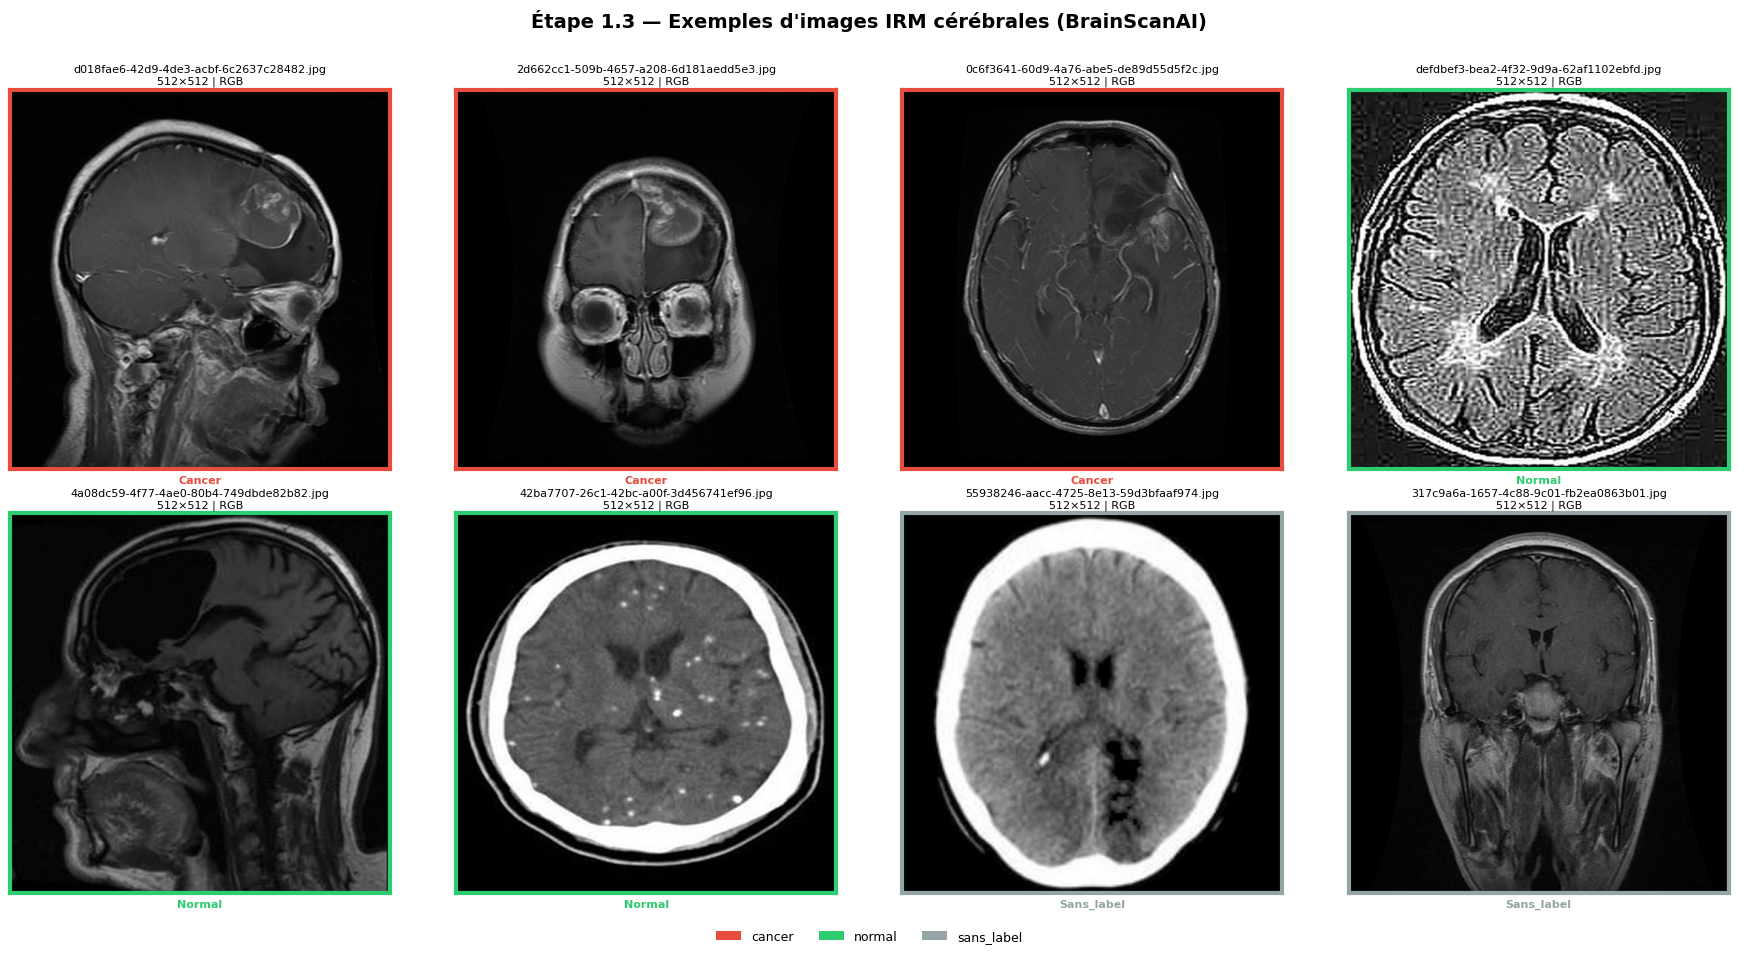

   💾  Figure sauvegardée → outputs/etape1/exemples_images.png

────────────────────────────────────────────────────────────
📊  Histogrammes des intensités de pixels
────────────────────────────────────────────────────────────
   📊  cancer        μ=42.4  σ=42.7  min=0  max=255
   📊  normal        μ=100.6  σ=73.9  min=0  max=255


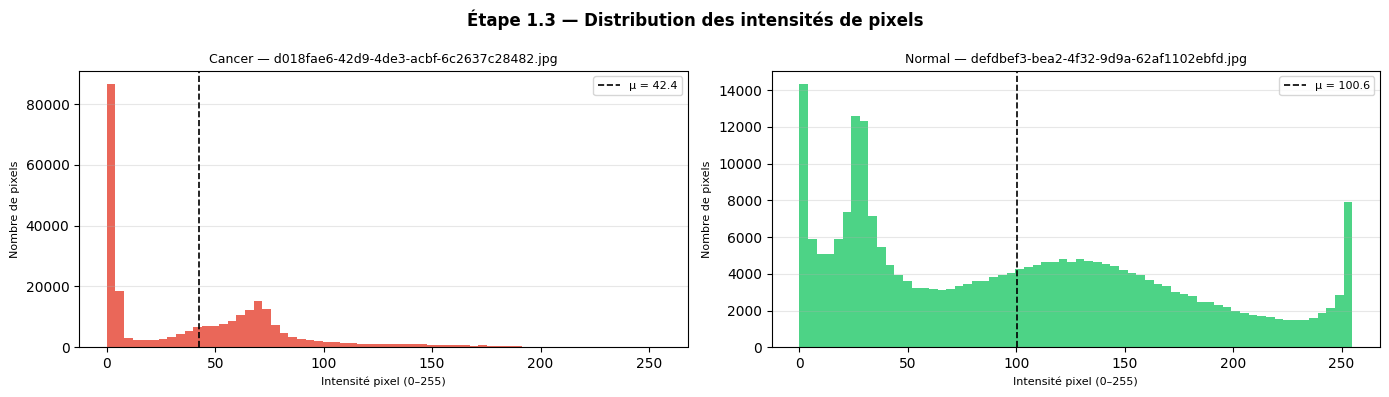

   💾  Histogrammes sauvegardés → outputs/etape1/histogrammes_intensites.png

────────────────────────────────────────────────────────────
📝  Note qualité — Observations manuelles
────────────────────────────────────────────────────────────

   ⚠️  En parcourant manuellement le dataset, plusieurs points de vigilance
       ont été identifiés et devront être pris en compte lors du preprocessing :

       • 📉  Images de faible qualité  : certaines images présentent du flou,
             du bruit ou un contraste insuffisant.
       • 🔄  Images déformées          : quelques images semblent étirées ou
             mal recadrées, ce qui pourrait biaiser l'apprentissage.
       • 🔭  Prises de vue hétérogènes : le dataset mélange des vues de face
             et des vues de profil, ce qui introduit une variabilité
             anatomique non liée à la pathologie.

   ➡️  Ces observations orienteront les choix de data augmentation et de
       filtrage qualité dans les étapes suivantes.

✅  Sous

In [3]:

# =============================================================================
# 🖼️  Sous-étape 1.3 : Visualisation et analyse technique des images
# =============================================================================
# Objectif :
#   Inspecter visuellement un échantillon représentatif d'images IRM pour
#   détecter d'éventuelles anomalies (résolutions mixtes, modes de couleur
#   hétérogènes, artefacts) avant toute étape de preprocessing. Cette
#   analyse est indispensable pour faire les bons choix de transformation.
# =============================================================================

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path

# ── Chemins vers les sous-dossiers ───────────────────────────────────────────
cancer_dir    = Path(DATA_ROOT) / "avec_labels" / "cancer"
normal_dir    = Path(DATA_ROOT) / "avec_labels" / "normal"
unlabeled_dir = Path(DATA_ROOT) / "sans_label"

# Si le notebook tourne depuis notebook/, on remonte d'un niveau
if not cancer_dir.exists():
    cancer_dir    = Path("..") / DATA_ROOT / "avec_labels" / "cancer"
    normal_dir    = Path("..") / DATA_ROOT / "avec_labels" / "normal"
    unlabeled_dir = Path("..") / DATA_ROOT / "sans_label"

cancer_dir    = cancer_dir.resolve()
normal_dir    = normal_dir.resolve()
unlabeled_dir = unlabeled_dir.resolve()

print("=" * 60)
print("🖼️   Sous-étape 1.3 — Visualisation des images IRM")
print("=" * 60)

# ── Dossier de sortie ─────────────────────────────────────────────────────────
OUTPUT_DIR = Path("outputs/etape1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Fonctions utilitaires ─────────────────────────────────────────────────────
_IMG_EXTENSIONS = {".png", ".jpg", ".jpeg"}

def list_images(directory: Path) -> list[Path]:
    """Retourne la liste triée de toutes les images d'un dossier."""
    return sorted([p for p in directory.rglob("*") if p.suffix.lower() in _IMG_EXTENSIONS])

def load_image_info(path: Path) -> dict:
    """Charge une image PIL et extrait ses métadonnées."""
    img = Image.open(path)
    return {
        "path"  : path,
        "image" : img,
        "size"  : img.size,           # (width, height)
        "mode"  : img.mode,
        "format": img.format or path.suffix.lstrip(".").upper(),
    }

# ── Collecte des fichiers ─────────────────────────────────────────────────────
cancer_files    = list_images(cancer_dir)
normal_files    = list_images(normal_dir)
unlabeled_files = list_images(unlabeled_dir)

print(f"\n📂  Fichiers trouvés :")
print(f"   🔴  cancer    : {len(cancer_files):>5} images  ({cancer_dir})")
print(f"   🟢  normal    : {len(normal_files):>5} images  ({normal_dir})")
print(f"   ⚪  sans_label: {len(unlabeled_files):>5} images  ({unlabeled_dir})")

# ── Sélection aléatoire reproductible ────────────────────────────────────────
rng = random.Random(RANDOM_SEED)

N_CANCER    = min(3, len(cancer_files))
N_NORMAL    = min(3, len(normal_files))
N_UNLABELED = min(2, len(unlabeled_files))

sample_cancer    = rng.sample(cancer_files,    N_CANCER)    if N_CANCER    else []
sample_normal    = rng.sample(normal_files,    N_NORMAL)    if N_NORMAL    else []
sample_unlabeled = rng.sample(unlabeled_files, N_UNLABELED) if N_UNLABELED else []

samples = (
    [(p, "cancer 🔴")     for p in sample_cancer]
  + [(p, "normal 🟢")     for p in sample_normal]
  + [(p, "sans_label ⚪") for p in sample_unlabeled]
)

print(f"\n🎲  Sélection aléatoire (seed={RANDOM_SEED}) :")
print(f"   → {N_CANCER} images cancer, {N_NORMAL} images normal, {N_UNLABELED} images sans_label")

# ── Analyse technique de chaque image ────────────────────────────────────────
print("\n" + "─" * 60)
print("🔬  Analyse technique des images sélectionnées")
print("─" * 60)

infos = []
for path, label in samples:
    info = load_image_info(path)
    info["label"] = label
    infos.append(info)
    w, h = info["size"]
    print(f"\n   📄  {info['path'].name}")
    print(f"       Chemin  : {info['path']}")
    print(f"       Taille  : {w} × {h} px")
    print(f"       Mode    : {info['mode']}")
    print(f"       Format  : {info['format']}")

# ── Vérification de l'homogénéité des résolutions ────────────────────────────
print("\n" + "─" * 60)
print("📐  Vérification de l'homogénéité des résolutions")
print("─" * 60)

# Contrôle sur l'ensemble complet des images (pas seulement l'échantillon)
all_files  = cancer_files + normal_files + unlabeled_files
sizes      = set()
modes      = set()
for p in all_files:
    try:
        with Image.open(p) as img:
            sizes.add(img.size)
            modes.add(img.mode)
    except Exception:
        pass

if len(sizes) == 1:
    (w, h) = next(iter(sizes))
    print(f"   ✅  Résolution unique : {w} × {h} px — toutes les images sont homogènes")
else:
    print(f"   ⚠️  {len(sizes)} résolutions différentes détectées :")
    for s in sorted(sizes):
        print(f"        • {s[0]} × {s[1]} px")
    print("   ➡️  Un redimensionnement uniforme sera nécessaire en preprocessing")

if len(modes) == 1:
    print(f"   ✅  Mode couleur unique : {next(iter(modes))}")
else:
    print(f"   ⚠️  {len(modes)} modes couleur différents : {modes}")

# ── Figure principale 2×4 ────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("🎨  Génération de la figure principale (2×4)")
print("─" * 60)

N_COLS  = 4
N_ROWS  = 2
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, 9))
axes_flat = axes.flatten()

fig.suptitle(
    "Étape 1.3 — Exemples d'images IRM cérébrales (BrainScanAI)",
    fontsize=14, fontweight="bold", y=1.01
)

for ax, info in zip(axes_flat, infos):
    img = info["image"]
    w, h = info["size"]
    cmap = "gray" if info["mode"] in ("L", "I", "F") else None
    disp_img = img.convert("L") if info["mode"] not in ("L", "RGB", "RGBA") else img
    ax.imshow(disp_img, cmap=cmap, aspect="equal")
    ax.set_title(
        f"{info['path'].name}\n{w}×{h} | {info['mode']}",
        fontsize=8, pad=4
    )
    # Bandeau de couleur selon la classe
    color_map = {"cancer 🔴": "#e74c3c", "normal 🟢": "#2ecc71", "sans_label ⚪": "#95a5a6"}
    color = color_map.get(info["label"], "#bdc3c7")
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])
    label_text = info["label"].split()[0].capitalize()
    ax.set_xlabel(label_text, fontsize=8, color=color, fontweight="bold")

# Masquer les axes vides si < 8 images
for ax in axes_flat[len(infos):]:
    ax.set_visible(False)

# Légende des couleurs
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="cancer"),
    Patch(facecolor="#2ecc71", label="normal"),
    Patch(facecolor="#95a5a6", label="sans_label"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.04), fontsize=9, frameon=False)

plt.tight_layout()
out_path_main = OUTPUT_DIR / "exemples_images.png"
fig.savefig(out_path_main, dpi=150, bbox_inches="tight")
plt.show()
print(f"   💾  Figure sauvegardée → {out_path_main}")

# ── Histogrammes d'intensité (1 cancer + 1 normal) ───────────────────────────
print("\n" + "─" * 60)
print("📊  Histogrammes des intensités de pixels")
print("─" * 60)

hist_samples = []
if sample_cancer:
    hist_samples.append((sample_cancer[0], "cancer", "#e74c3c"))
if sample_normal:
    hist_samples.append((sample_normal[0], "normal", "#2ecc71"))

if hist_samples:
    fig2, axes2 = plt.subplots(1, len(hist_samples), figsize=(7 * len(hist_samples), 4))
    if len(hist_samples) == 1:
        axes2 = [axes2]

    fig2.suptitle(
        "Étape 1.3 — Distribution des intensités de pixels",
        fontsize=12, fontweight="bold"
    )

    for ax2, (path, label, color) in zip(axes2, hist_samples):
        img   = Image.open(path).convert("L")
        pixels = np.array(img).flatten()
        ax2.hist(pixels, bins=64, color=color, alpha=0.85, edgecolor="none")
        ax2.set_title(f"{label.capitalize()} — {path.name}", fontsize=9)
        ax2.set_xlabel("Intensité pixel (0–255)", fontsize=8)
        ax2.set_ylabel("Nombre de pixels", fontsize=8)
        ax2.axvline(pixels.mean(), color="black", linestyle="--",
                    linewidth=1.2, label=f"μ = {pixels.mean():.1f}")
        ax2.legend(fontsize=8)
        ax2.grid(axis="y", alpha=0.3)
        print(f"   📊  {label:<12}  μ={pixels.mean():.1f}  σ={pixels.std():.1f}"
              f"  min={pixels.min()}  max={pixels.max()}")

    plt.tight_layout()
    out_path_hist = OUTPUT_DIR / "histogrammes_intensites.png"
    fig2.savefig(out_path_hist, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   💾  Histogrammes sauvegardés → {out_path_hist}")

# ── Note qualité — observation manuelle du dataset ───────────────────────────
print("\n" + "─" * 60)
print("📝  Note qualité — Observations manuelles")
print("─" * 60)
print("""
   ⚠️  En parcourant manuellement le dataset, plusieurs points de vigilance
       ont été identifiés et devront être pris en compte lors du preprocessing :

       • 📉  Images de faible qualité  : certaines images présentent du flou,
             du bruit ou un contraste insuffisant.
       • 🔄  Images déformées          : quelques images semblent étirées ou
             mal recadrées, ce qui pourrait biaiser l'apprentissage.
       • 🔭  Prises de vue hétérogènes : le dataset mélange des vues de face
             et des vues de profil, ce qui introduit une variabilité
             anatomique non liée à la pathologie.

   ➡️  Ces observations orienteront les choix de data augmentation et de
       filtrage qualité dans les étapes suivantes.
""")

# ── Bilan ─────────────────────────────────────────────────────────────────────
print("=" * 60)
print("✅  Sous-étape 1.3 terminée — Visualisation et analyse technique")
print("=" * 60)


## 🏷️ Sous-étape 1.4 — Distribution des labels

> **Organisation des labels par dossiers (pas de fichier CSV séparé)**  
> Dans ce dataset, les labels ne sont **pas** stockés dans un fichier CSV ou JSON externe.  
> Chaque image est classée selon le **sous-dossier** dans lequel elle réside :
> - `avec_labels/cancer/` → images présentant une tumeur cérébrale
> - `avec_labels/normal/` → images sans tumeur détectée
> - `sans_label/` → images non annotées (sans classe assignée)
>
> Cette organisation est directement compatible avec `torchvision.datasets.ImageFolder`, ce qui simplifie le chargement en modélisation.

> **Distribution parfaitement équilibrée (50 / 50)**  
> Le sous-ensemble labellisé présente une répartition **égale** entre les deux classes (`cancer` et `normal`).  
> Cela élimine tout risque de biais lié au déséquilibre des classes : aucun *oversampling* ni *undersampling* ne sera nécessaire pour l'entraînement.

🏷️   Sous-étape 1.4 — Distribution des labels

📂  Chemins analysés :
   🔴  /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/avec_labels/cancer
   🟢  /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/avec_labels/normal
   ⚪  /home/valentin/Env_Python/OC_P9/mri_dataset_brain_cancer_oc/sans_label

────────────────────────────────────────────────
   Classe                   Nombre  Pourcentage
   ────────────────────── ──────── ────────────
   🔴  cancer                     50       50.00%
   🟢  normal                     50       50.00%
   ────────────────────── ──────── ────────────
   TOTAL labellisées           100      100.00%
────────────────────────────────────────────────

   📸  Images labellisées   :    100
   ⚪  Images sans label    :  1,406
   ────────────────────────────────
   🖼️   Total général        :  1,506



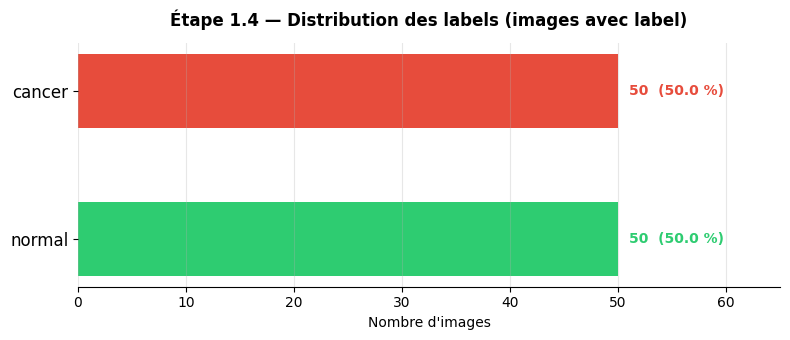

   💾  Graphique sauvegardé → outputs/etape1/labels_distribution.png
   💾  CSV sauvegardé → outputs/etape1/labels_distribution.csv

✅  Sous-étape 1.4 terminée — Distribution des labels analysée


In [4]:
# =============================================================================
# 🏷️  Sous-étape 1.4 : Analyse de la distribution des labels
# =============================================================================
# Objectif :
#   Quantifier précisément le nombre d'images par classe (cancer / normal)
#   ainsi que les images sans label, et vérifier l'équilibre du dataset.
#   Une distribution équilibrée est un prérequis fondamental pour éviter
#   les biais d'apprentissage sans recourir à des techniques de rééchantillonnage.
# =============================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 60)
print("🏷️   Sous-étape 1.4 — Distribution des labels")
print("=" * 60)

# ── Résolution des chemins ────────────────────────────────────────────────────
_base = Path(DATA_ROOT)
if not _base.exists():
    _base = Path("..") / DATA_ROOT

_cancer_dir    = (_base / "avec_labels" / "cancer").resolve()
_normal_dir    = (_base / "avec_labels" / "normal").resolve()
_unlabeled_dir = (_base / "sans_label").resolve()

# ── Comptage des images ───────────────────────────────────────────────────────
_IMG_EXTS = {".png", ".jpg", ".jpeg"}

def _count_images(directory: Path) -> int:
    """Compte toutes les images (png/jpg/jpeg) dans un dossier."""
    return len([p for p in directory.rglob("*") if p.suffix.lower() in _IMG_EXTS])

n_cancer       = _count_images(_cancer_dir)
n_normal       = _count_images(_normal_dir)
n_labeled      = n_cancer + n_normal
n_unlabeled    = _count_images(_unlabeled_dir)
n_total        = n_labeled + n_unlabeled

print(f"\n📂  Chemins analysés :")
print(f"   🔴  {_cancer_dir}")
print(f"   🟢  {_normal_dir}")
print(f"   ⚪  {_unlabeled_dir}")

# ── Construction du DataFrame ─────────────────────────────────────────────────
df_dist = pd.DataFrame({
    "Classe"      : ["cancer", "normal"],
    "Nombre"      : [n_cancer, n_normal],
    "Pourcentage" : [
        round(n_cancer / n_labeled * 100, 2) if n_labeled else 0,
        round(n_normal / n_labeled * 100, 2) if n_labeled else 0,
    ],
})

# ── Tableau résumé formaté ────────────────────────────────────────────────────
print()
print("─" * 48)
print(f"   {'Classe':<22} {'Nombre':>8} {'Pourcentage':>12}")
print(f"   {'─' * 22} {'─' * 8} {'─' * 12}")
for _, row in df_dist.iterrows():
    icon = "🔴" if row["Classe"] == "cancer" else "🟢"
    print(f"   {icon}  {row['Classe']:<20} {int(row['Nombre']):>8,} {row['Pourcentage']:>11.2f}%")
print(f"   {'─' * 22} {'─' * 8} {'─' * 12}")
print(f"   {'TOTAL labellisées':<22} {n_labeled:>8,} {'100.00':>11}%")
print("─" * 48)
print()
print(f"   📸  Images labellisées   : {n_labeled:>6,}")
print(f"   ⚪  Images sans label    : {n_unlabeled:>6,}")
print(f"   {'─' * 32}")
print(f"   🖼️   Total général        : {n_total:>6,}")
print()

# ── Barplot horizontal (seaborn) ──────────────────────────────────────────────
_palette = {"cancer": "#e74c3c", "normal": "#2ecc71"}
_colors  = [_palette[c] for c in df_dist["Classe"]]

fig, ax = plt.subplots(figsize=(8, 3.5))

bars = ax.barh(
    df_dist["Classe"],
    df_dist["Nombre"],
    color=_colors,
    edgecolor="none",
    height=0.5,
)

# Annotations valeur + pourcentage au bout de chaque barre
for bar, (_, row) in zip(bars, df_dist.iterrows()):
    ax.text(
        bar.get_width() + n_labeled * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['Nombre']):,}  ({row['Pourcentage']:.1f} %)",
        va="center", ha="left", fontsize=10, fontweight="bold",
        color=_palette[row["Classe"]],
    )

ax.set_xlabel("Nombre d'images", fontsize=10)
ax.set_title(
    "Étape 1.4 — Distribution des labels (images avec label)",
    fontsize=12, fontweight="bold", pad=12,
)
ax.invert_yaxis()
ax.set_xlim(0, max(df_dist["Nombre"]) * 1.30)
sns.despine(ax=ax, left=True)
ax.tick_params(axis="y", labelsize=12)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

_out_fig = Path("outputs/etape1") / "labels_distribution.png"
_out_fig.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_out_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"   💾  Graphique sauvegardé → {_out_fig}")

# ── Sauvegarde CSV ────────────────────────────────────────────────────────────
_out_csv = Path("outputs/etape1") / "labels_distribution.csv"
df_dist.to_csv(_out_csv, index=False)
print(f"   💾  CSV sauvegardé → {_out_csv}")

print()
print("=" * 60)
print("✅  Sous-étape 1.4 terminée — Distribution des labels analysée")
print("=" * 60)


In [5]:

# =============================================================================
# 🔬 Sous-étape 1.5 : Contrôle qualité + Échantillon réduit
# =============================================================================
# Objectif :
#   Avant de lancer des pipelines coûteux (preprocessing, entraînement),
#   il est essentiel de vérifier la cohérence technique du dataset complet
#   et de constituer un échantillon réduit reproductible.
#
#   Cet échantillon de 300 images sera utilisé dans les étapes suivantes pour :
#     • Valider rapidement les transformations de preprocessing (étape 2)
#     • Prototyper et tester les architectures de modèles (étapes 3–4)
#     • Réduire les temps de calcul lors des phases exploratoires
#   Une fois les pipelines validés, ils seront appliqués au dataset complet.
#
#   Composition de l'échantillon (version améliorée) :
#     • 100 % des images labellisées (toutes les images cancer + normal)
#     • 200 images sans label sélectionnées aléatoirement (seed=42)
#     → Baseline supervisée plus solide qu'un tirage proportionnel
# =============================================================================

import json
import random
from pathlib import Path

import pandas as pd
from PIL import Image
from tqdm import tqdm

print("=" * 60)
print("🔬  Sous-étape 1.5 — Contrôle qualité + Échantillon réduit")
print("=" * 60)

# ── Résolution des chemins ────────────────────────────────────────────────────
_base = Path(DATA_ROOT)
if not _base.exists():
    _base = Path("..") / DATA_ROOT

_cancer_dir    = (_base / "avec_labels" / "cancer").resolve()
_normal_dir    = (_base / "avec_labels" / "normal").resolve()
_unlabeled_dir = (_base / "sans_label").resolve()

_IMG_EXTS = {".png", ".jpg", ".jpeg"}

def _collect_images(directory: Path, label: str) -> list[dict]:
    """Retourne la liste des images d'un dossier avec leur label."""
    return [
        {"path": str(p), "label": label}
        for p in sorted(directory.rglob("*"))
        if p.suffix.lower() in _IMG_EXTS
    ]

# ── 1. Collecte de tous les chemins ──────────────────────────────────────────
print("\n📂  Collecte des chemins d'images...")

all_records = (
    _collect_images(_cancer_dir,    "cancer")
  + _collect_images(_normal_dir,    "normal")
  + _collect_images(_unlabeled_dir, "sans_label")
)

n_total     = len(all_records)
n_cancer_t  = sum(1 for r in all_records if r["label"] == "cancer")
n_normal_t  = sum(1 for r in all_records if r["label"] == "normal")
n_unlabel_t = sum(1 for r in all_records if r["label"] == "sans_label")

print(f"   🔴  cancer      : {n_cancer_t:>6,} images")
print(f"   🟢  normal      : {n_normal_t:>6,} images")
print(f"   ⚪  sans_label  : {n_unlabel_t:>6,} images")
print(f"   {'─' * 30}")
print(f"   🖼️   Total       : {n_total:>6,} images")

# ── 2. Contrôle qualité sur 500 images aléatoires ────────────────────────────
print("\n" + "─" * 60)
print("🩺  Contrôle qualité (échantillon de 500 images)")
print("─" * 60)

QC_SAMPLE_SIZE = min(500, n_total)
random.seed(42)
qc_sample = random.sample(all_records, QC_SAMPLE_SIZE)

qc_sizes     : set  = set()
qc_modes     : set  = set()
n_corrupted  : int  = 0
corrupted_paths: list[str] = []

for record in tqdm(qc_sample, desc="   Vérification", unit="img", ncols=70):
    try:
        with Image.open(record["path"]) as img:
            qc_sizes.add(img.size)
            qc_modes.add(img.mode)
    except Exception:
        n_corrupted += 1
        corrupted_paths.append(record["path"])

print(f"\n   📐  Résolutions différentes détectées : {len(qc_sizes)}")
if len(qc_sizes) == 1:
    w, h = next(iter(qc_sizes))
    print(f"        ✅  Résolution unique : {w} × {h} px")
else:
    for s in sorted(qc_sizes):
        print(f"        • {s[0]} × {s[1]} px")
    print("   ➡️  Redimensionnement nécessaire en preprocessing")

print(f"\n   🎨  Modes couleur détectés : {qc_modes}")
if len(qc_modes) == 1:
    print(f"        ✅  Mode unique : {next(iter(qc_modes))}")
else:
    print("   ➡️  Conversion vers un mode uniforme nécessaire")

if n_corrupted == 0:
    print(f"\n   ✅  Aucune image corrompue détectée sur {QC_SAMPLE_SIZE} testées")
else:
    print(f"\n   ⚠️  {n_corrupted} image(s) corrompue(s) détectée(s) :")
    for cp in corrupted_paths:
        print(f"        • {cp}")

# ── 3. Constitution de l'échantillon réduit ───────────────────────────────────
print("\n" + "─" * 60)
print("🎲  Constitution de l'échantillon réduit (N=300, seed=42)")
print("─" * 60)
print("   Stratégie : 100 % des images labellisées + 200 images sans label")

SAMPLE_SIZE         = 300
N_UNLABELED_SAMPLE  = 200

# Groupement par label
_by_label: dict[str, list] = {"cancer": [], "normal": [], "sans_label": []}
for record in all_records:
    _by_label[record["label"]].append(record)

# Toutes les images labellisées (cancer + normal)
labeled_records = _by_label["cancer"] + _by_label["normal"]

# 200 images sans label tirées aléatoirement (seed=42)
random.seed(42)
unlabeled_pool    = _by_label["sans_label"]
chosen_unlabeled  = random.sample(unlabeled_pool, min(N_UNLABELED_SAMPLE, len(unlabeled_pool)))

sample_records = labeled_records + chosen_unlabeled

# Mélange final pour briser l'ordre par classe
random.seed(42)
random.shuffle(sample_records)

# Comptages dans l'échantillon
s_cancer   = sum(1 for r in sample_records if r["label"] == "cancer")
s_normal   = sum(1 for r in sample_records if r["label"] == "normal")
s_unlabel  = sum(1 for r in sample_records if r["label"] == "sans_label")

print(f"\n   🔴  cancer      : {s_cancer:>5} images  ({s_cancer / SAMPLE_SIZE * 100:.1f} %)")
print(f"   🟢  normal      : {s_normal:>5} images  ({s_normal / SAMPLE_SIZE * 100:.1f} %)")
print(f"   ⚪  sans_label  : {s_unlabel:>5} images  ({s_unlabel / SAMPLE_SIZE * 100:.1f} %)")
print(f"   {'─' * 42}")
print(f"   🖼️   Total       : {len(sample_records):>5} images")

# ── 4. Sauvegarde JSON ────────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("💾  Sauvegarde de l'échantillon")
print("─" * 60)

_out_dir = Path("outputs/etape1")
_out_dir.mkdir(parents=True, exist_ok=True)

_out_json = _out_dir / "sample_paths.json"
with open(_out_json, "w", encoding="utf-8") as f:
    json.dump(sample_records, f, ensure_ascii=False, indent=2)

print(f"\n   ✅  {len(sample_records)} chemins sauvegardés → {_out_json}")
print(f"       Format : liste de dicts {{\"path\": ..., \"label\": ...}}")

# ── 5. Résumé final ───────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("📋  RÉSUMÉ SOUS-ÉTAPE 1.5")
print("=" * 60)
print(f"""
   📊  Dataset complet
        Total images      : {n_total:,}
        cancer            : {n_cancer_t:,}
        normal            : {n_normal_t:,}
        sans_label        : {n_unlabel_t:,}

   🩺  Contrôle qualité (sur {QC_SAMPLE_SIZE} images)
        Résolutions uniques : {len(qc_sizes)}
        Modes couleur       : {len(qc_modes)}
        Images corrompues   : {n_corrupted}

   🎲  Échantillon réduit (N={SAMPLE_SIZE}, seed=42)
        Stratégie         : 100 % labellisées + 200 sans label
        cancer            : {s_cancer}  ({s_cancer / SAMPLE_SIZE * 100:.1f} %)
        normal            : {s_normal}  ({s_normal / SAMPLE_SIZE * 100:.1f} %)
        sans_label        : {s_unlabel}  ({s_unlabel / SAMPLE_SIZE * 100:.1f} %)
        Fichier JSON      : {_out_json}
""")

print("=" * 60)
print("✅  Sous-étape 1.5 terminée — Contrôle qualité effectué")
print("=" * 60)


🔬  Sous-étape 1.5 — Contrôle qualité + Échantillon réduit

📂  Collecte des chemins d'images...
   🔴  cancer      :     50 images
   🟢  normal      :     50 images
   ⚪  sans_label  :  1,406 images
   ──────────────────────────────
   🖼️   Total       :  1,506 images

────────────────────────────────────────────────────────────
🩺  Contrôle qualité (échantillon de 500 images)
────────────────────────────────────────────────────────────


   Vérification: 100%|██████████| 500/500 [00:00<00:00, 41612.64img/s]


   📐  Résolutions différentes détectées : 1
        ✅  Résolution unique : 512 × 512 px

   🎨  Modes couleur détectés : {'RGB'}
        ✅  Mode unique : RGB

   ✅  Aucune image corrompue détectée sur 500 testées

────────────────────────────────────────────────────────────
🎲  Constitution de l'échantillon réduit (N=300, seed=42)
────────────────────────────────────────────────────────────
   Stratégie : 100 % des images labellisées + 200 images sans label

   🔴  cancer      :    50 images  (16.7 %)
   🟢  normal      :    50 images  (16.7 %)
   ⚪  sans_label  :   200 images  (66.7 %)
   ──────────────────────────────────────────
   🖼️   Total       :   300 images

────────────────────────────────────────────────────────────
💾  Sauvegarde de l'échantillon
────────────────────────────────────────────────────────────

   ✅  300 chemins sauvegardés → outputs/etape1/sample_paths.json
       Format : liste de dicts {"path": ..., "label": ...}

📋  RÉSUMÉ SOUS-ÉTAPE 1.5

   📊  Dataset complet
